In [ ]:
# env is norm_scRNAseq

In [42]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import seaborn as sns
import random
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt

from matplotlib import colors
import matplotlib.cm as cm

In [ ]:
# Set global seeds
np.random.seed(42)
random.seed(42)

In [2]:
sc.settings.set_figure_params(figsize=(10, 10), facecolor="white")

In [ ]:
adata = sc.read_h5ad(
    "../adata/IBD_preprocessing_dedoublet.h5ad"
)
adata

AnnData object with n_obs × n_vars = 183391 × 38606
    obs: 'sample', 'GC_Sample_Number', 'Gender', 'Date_of_surgery', 'Location', 'Disease', 'Segment', 'Age', 'Cells_prefix', 'Condition', 'Disease_segment', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'outlier_colors', 'mt_outlier', 'mt_outlier_colors', 'leiden', 'cell_type', 'scDblFinder_score', 'scDblFinder_class'
    var: 'gene_ids', 'feature_types', 'genome', 'gene_names', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'mt_outlier_colors_colors', 'neighbors', 'outlier_colors_colors', 'pca', 'sample_colors', 'scDblFinder_c

In [4]:
print(adata.obs["sample"].value_counts())

sample
GC1001407_E3         8936
GC1001406_D3         8820
GC1001328_H2         8673
GC117092_SI-GA-E8    7447
GC1002819_G6         7023
GC1001405_H3         6727
GC1002817_E6         6460
GC117919_SI-GA-D4    6151
GC1001330_A3         5838
GC117076_SI-GA-A8    5745
GC117077_SI-GA-B8    5633
GC1002818_F6         5611
GC092332_F2          5535
GC117090_SI-GA-C8    5341
GC1001806_F4         5287
GC1001332_C3         5131
GC117091_SI-GA-D8    4955
GC117075_SI-GA-H7    4941
GC092331_E2          4885
GC087836_E1          4825
GC092577_G2          4741
GC1001805_E4         4674
GC117918_SI-GA-C4    4628
GC088247_F1          4526
GC1001408_F3         4139
GC1001791_D4         4094
GC090246_A2          4012
GC1001331_B3         3964
GC092330_D2          3949
GC1001807_G4         3883
GC1001790_C4         3536
GC088249_H1          3360
GC117917_SI-GA-B4    3315
GC1001789_B4         3308
GC088248_G1          3298
Name: count, dtype: int64


In [5]:
# sanity check
display("Max in adata.X:  ", adata.X.max())
display("Max in layer counts:  ", adata.layers["counts"].max())
display("Max in layer soupx counts:  ", adata.layers["soupX_counts"].max())

'Max in adata.X:  '

69119.0

'Max in layer counts:  '

69325.0

'Max in layer soupx counts:  '

69119.0

In [6]:
display(adata.var)

,gene_ids,feature_types,genome,gene_names,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection
gene,,,,,,,,,,,,,,,,,
DDX11L2,ENSG00000290825,Gene Expression,GRCh38,DDX11L2,False,2,0.000008,0.000008,99.999155,2.0,1.098612,False,0.000011,0.001238,-0.019465,0,False
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,MIR1302-2HG,False,3,0.000013,0.000013,99.998733,3.0,1.386294,False,0.000005,-0.098897,-0.139424,0,False
FAM138A,ENSG00000237613,Gene Expression,GRCh38,FAM138A,False,0,0.000000,0.000000,100.000000,0.0,0.000000,False,0.000000,0.000000,0.000000,0,False
ENSG00000290826,ENSG00000290826,Gene Expression,GRCh38,ENSG00000290826,False,2,0.000008,0.000008,99.999155,2.0,1.098612,False,0.000002,-0.088712,-0.118852,0,False
OR4F5,ENSG00000186092,Gene Expression,GRCh38,OR4F5,False,1,0.000004,0.000004,99.999578,1.0,0.693147,False,0.000002,-0.026092,-0.045030,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000277836,ENSG00000277836,Gene Expression,GRCh38,ENSG00000277836,False,228,0.002129,0.002127,99.903696,504.0,6.224558,False,0.000623,-0.383446,-0.855406,0,False
ENSG00000278633,ENSG00000278633,Gene Expression,GRCh38,ENSG00000278633,False,6,0.000025,0.000025,99.997466,6.0,1.945910,False,0.000026,-0.062530,-0.087715,0,False
ENSG00000276017,ENSG00000276017,Gene Expression,GRCh38,ENSG00000276017,False,5,0.000021,0.000021,99.997888,5.0,1.791759,False,0.000006,-0.129746,-0.202292,0,False


In [ ]:
# quality check calcuate again
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=[20],log1p=True)

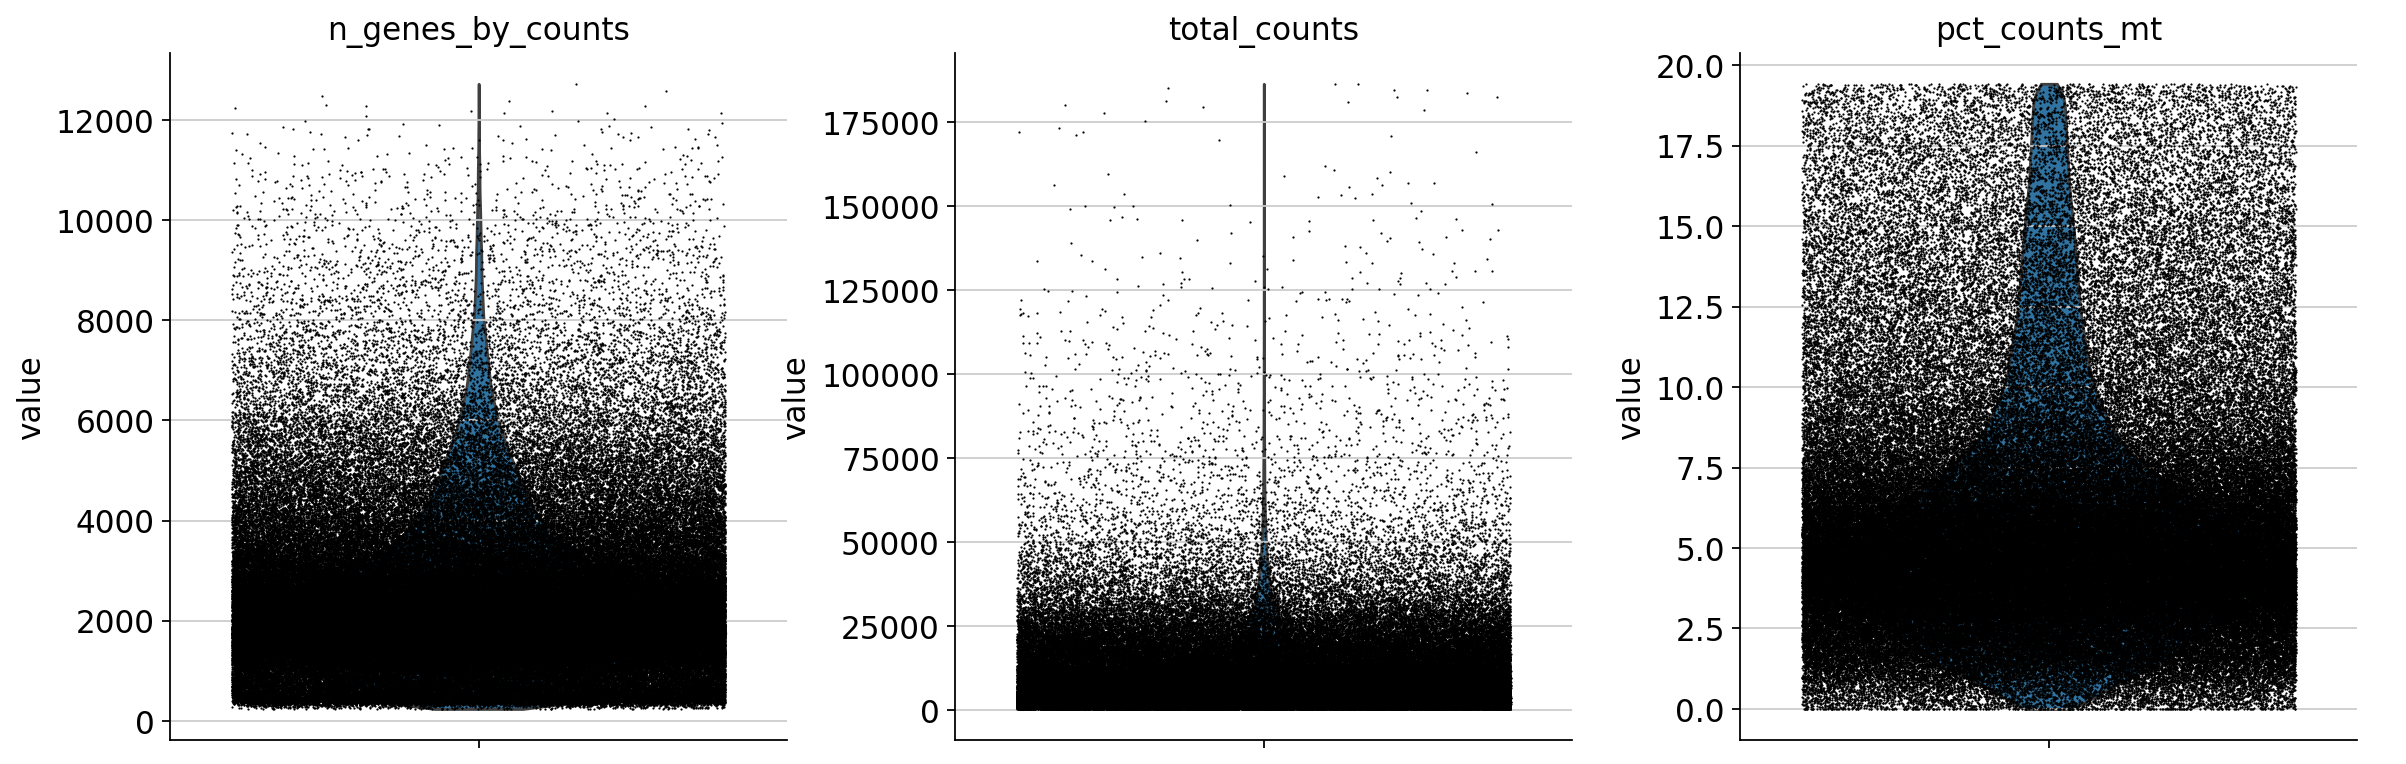

In [8]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

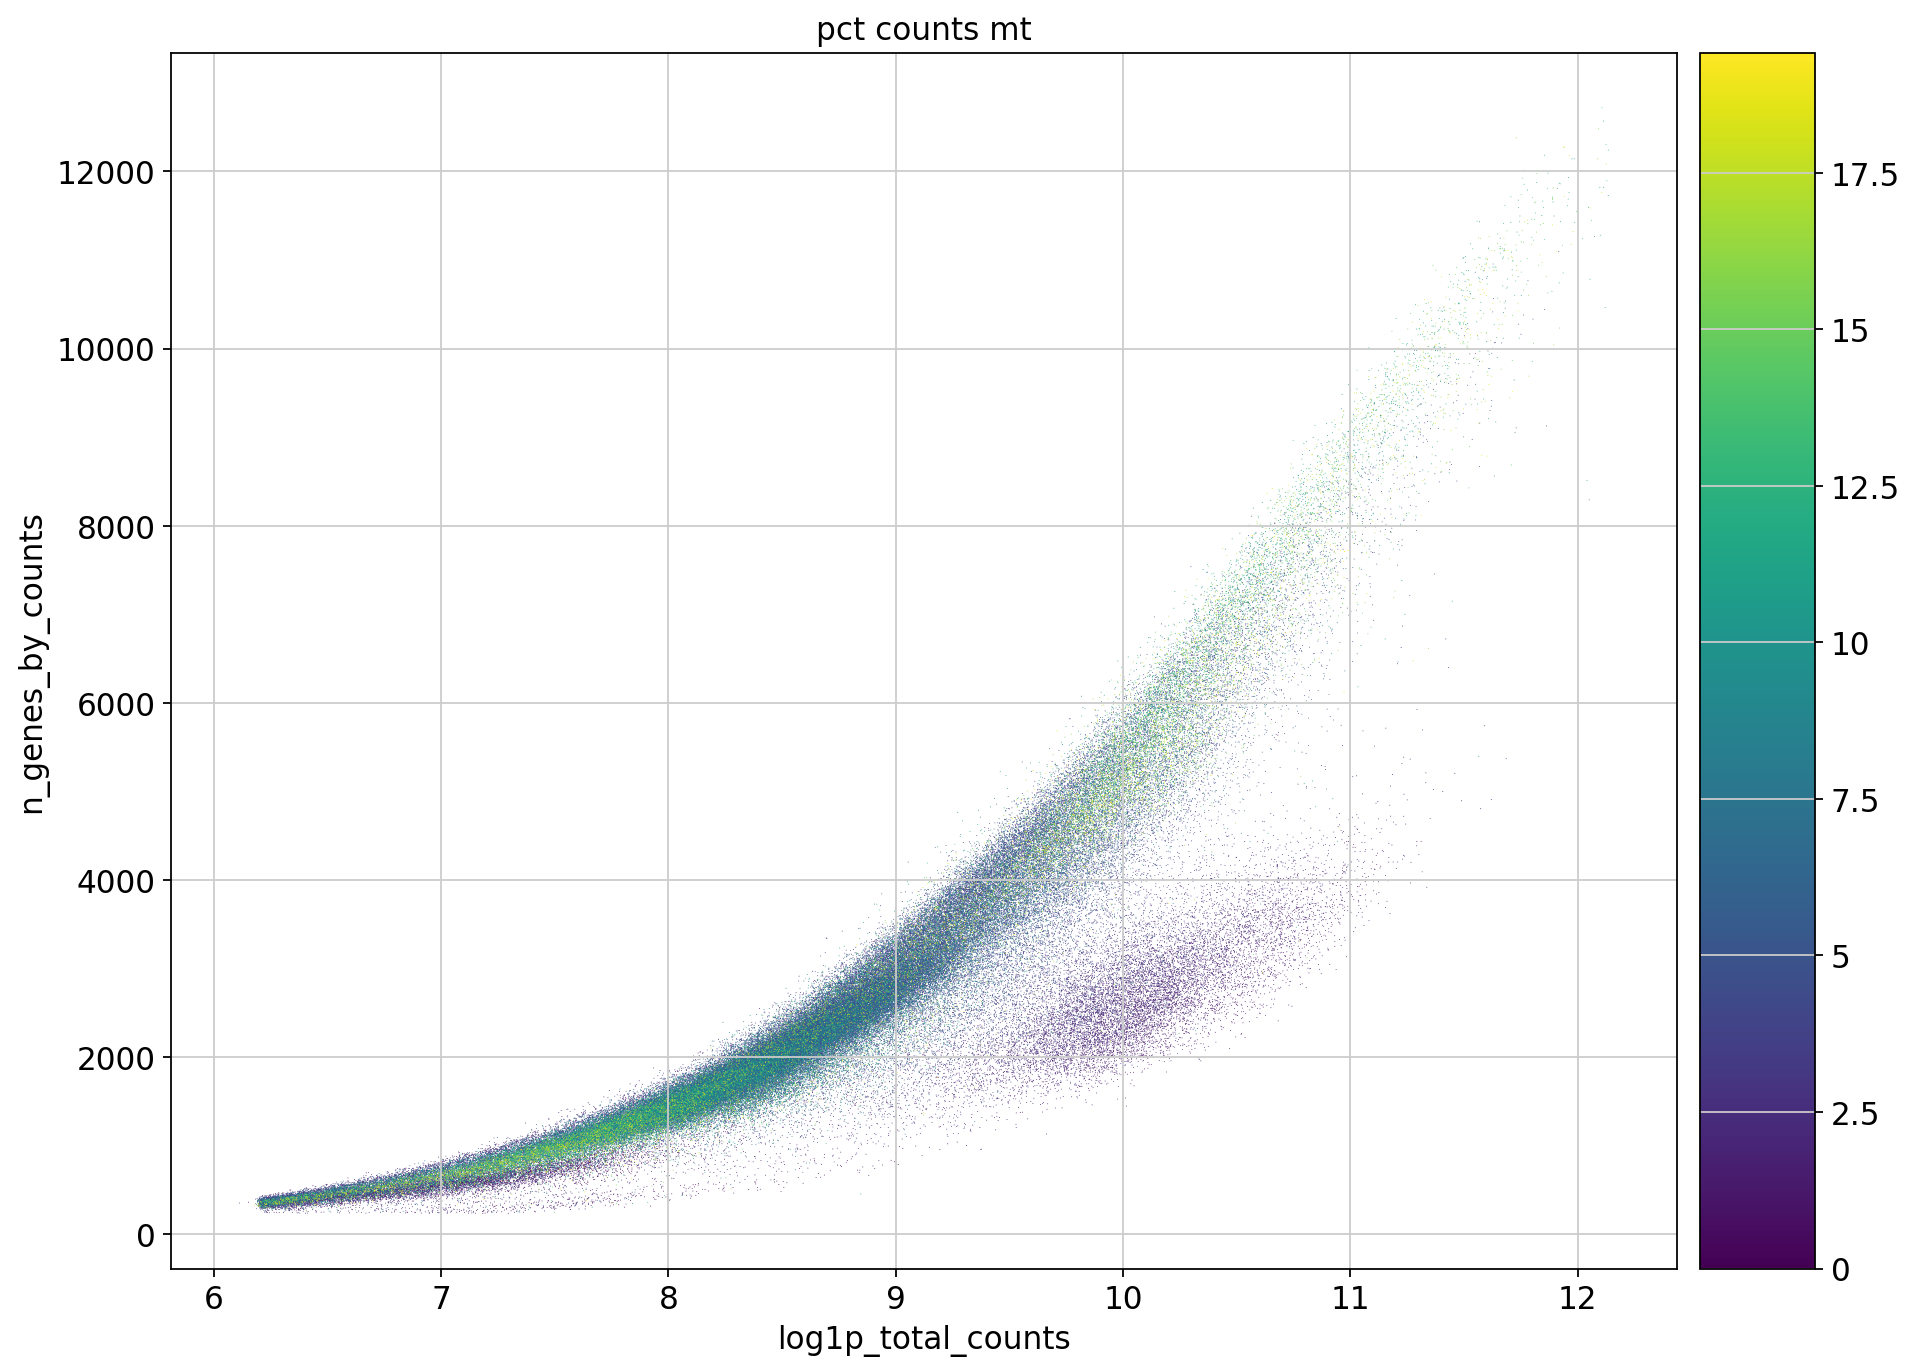

In [10]:
sc.pl.scatter(adata, x='log1p_total_counts', y='n_genes_by_counts', color='pct_counts_mt')

In [ ]:
sc.pl.scatter(adata, x='log1p_total_counts', y='n_genes_by_counts', color='sample', size = 3)

In [12]:
adata.X = adata.layers['soupX_counts'].copy() # to be sure to work on soupx
adata

AnnData object with n_obs × n_vars = 183391 × 38606
    obs: 'sample', 'GC_Sample_Number', 'Gender', 'Date_of_surgery', 'Location', 'Disease', 'Segment', 'Age', 'Cells_prefix', 'Condition', 'Disease_segment', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'outlier_colors', 'mt_outlier', 'mt_outlier_colors', 'leiden', 'cell_type', 'scDblFinder_score', 'scDblFinder_class'
    var: 'gene_ids', 'feature_types', 'genome', 'gene_names', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'mt_outlier_colors_colors', 'neighbors', 'outlier_colors_colors', 'pca', 'sample_colors', 'scDblFinder_c

In [13]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.tl.pca(adata, svd_solver='arpack')

In [ ]:
sc.pp.neighbors(adata) # automatically scanpy uses 50 PCs
sc.tl.umap(adata, random_state=42)

In [20]:
# sanity check
display("Max in adata.X:  ", adata.X.max())
display("Max in layer counts:  ", adata.layers["counts"].max())
display("Max in layer soupx counts:  ", adata.layers["soupX_counts"].max())

'Max in adata.X:  '

8.353765179115399

'Max in layer counts:  '

69325.0

'Max in layer soupx counts:  '

69119.0

In [ ]:
sc.pl.umap(
    adata,
    color="sample",
    size=8,
    legend_loc="right margin"
)

In [22]:
%%time
sc.external.pp.bbknn(adata, batch_key="sample")

CPU times: user 1min 21s, sys: 1.77 s, total: 1min 23s
Wall time: 1min 23s


In [ ]:
sc.tl.umap(adata, random_state=42)

In [ ]:
sc.pl.umap(adata, color="sample", size = 8)

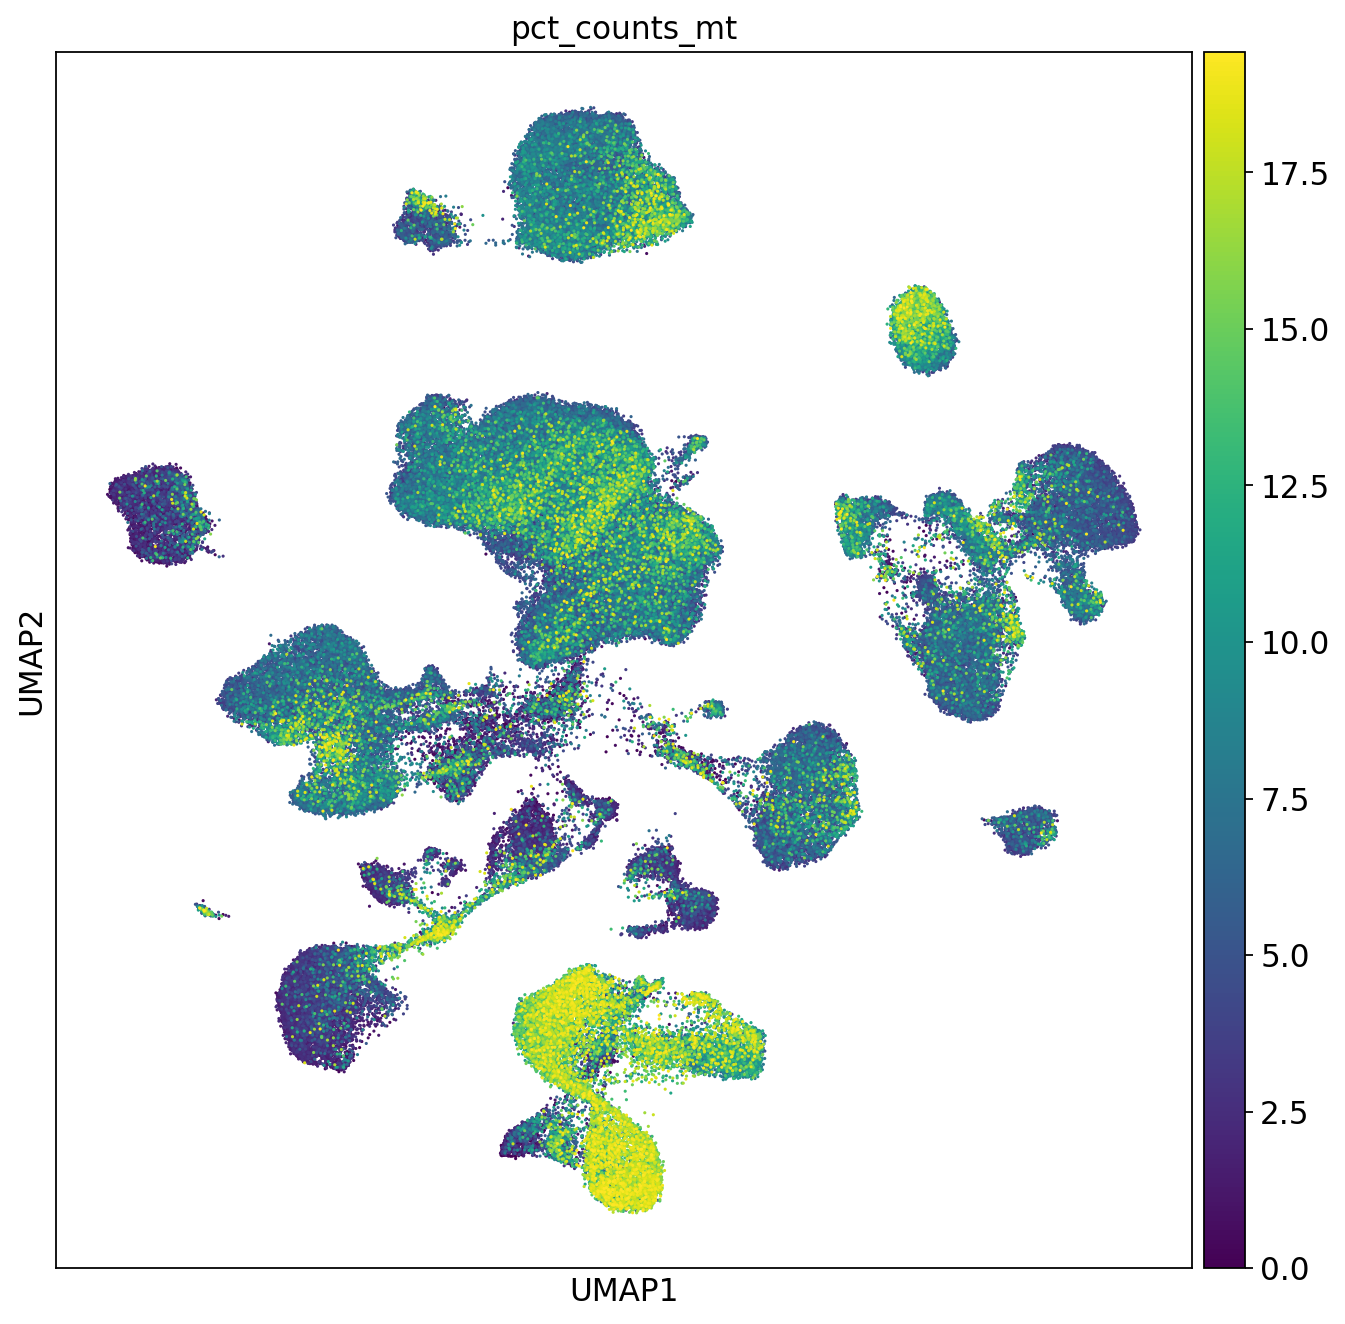

In [25]:
sc.pl.umap(adata, color=["pct_counts_mt"], size = 8)

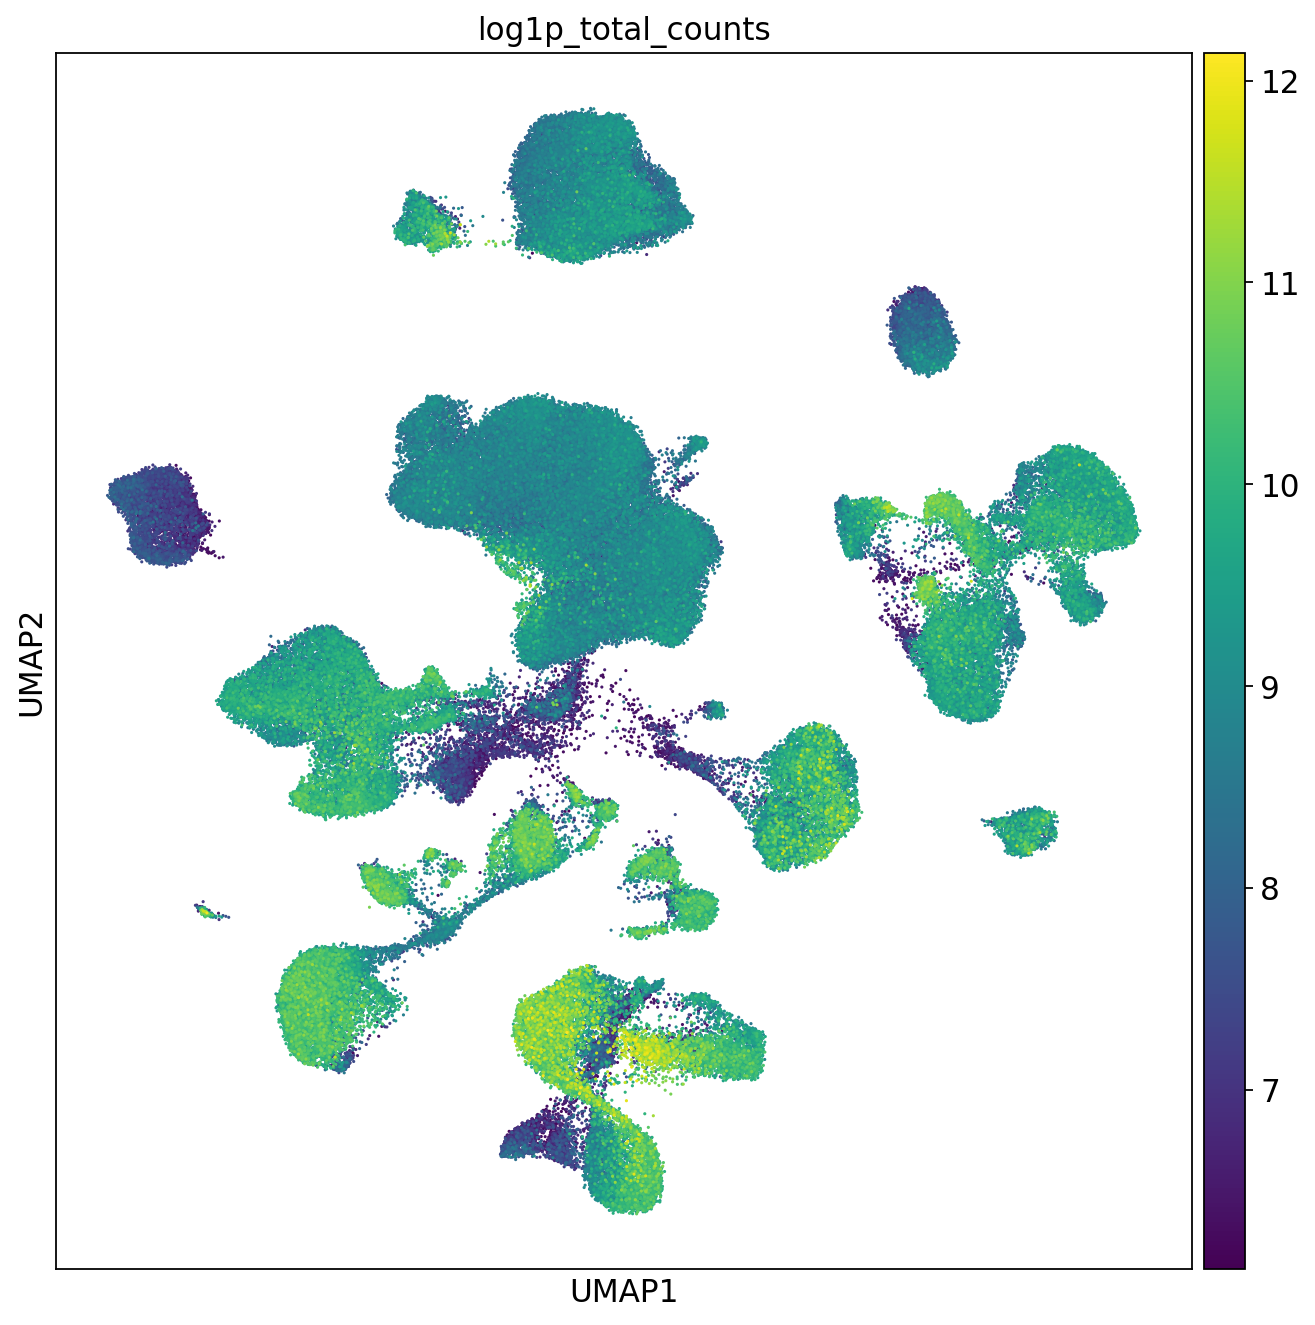

In [26]:
sc.pl.umap(adata, color=["log1p_total_counts"], size = 8)

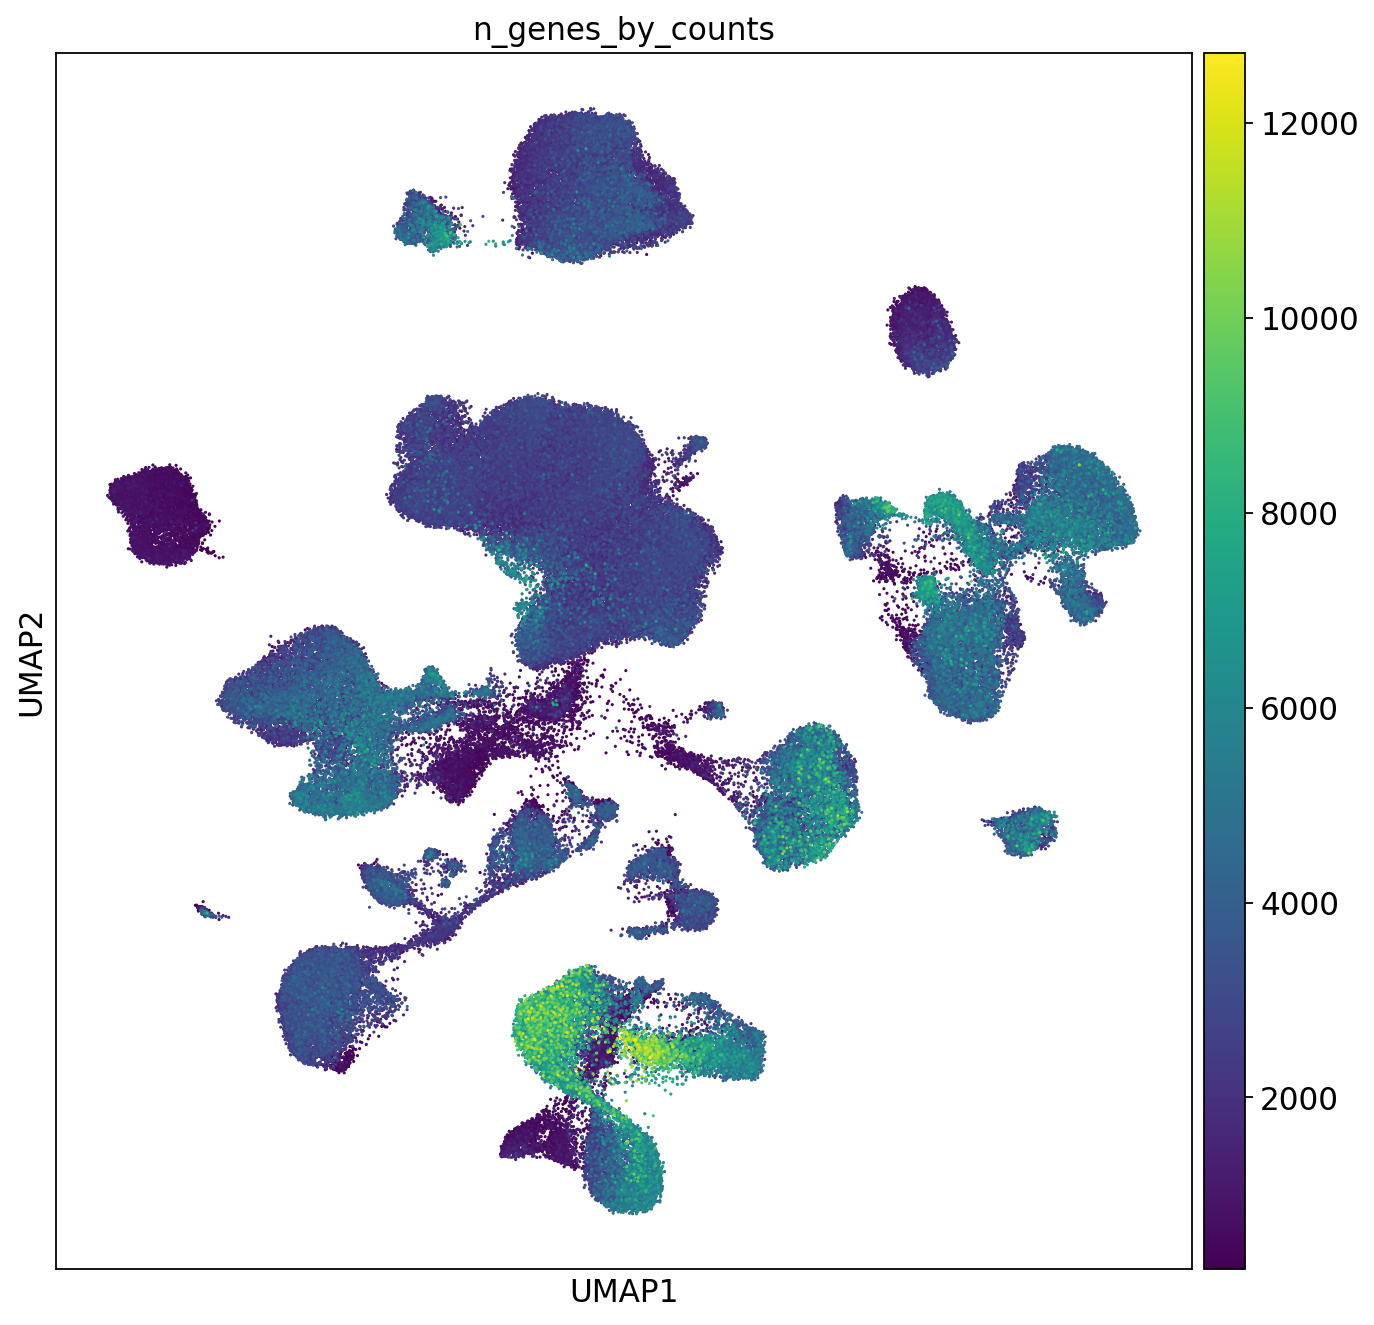

In [27]:
sc.pl.umap(adata, color=["n_genes_by_counts"], size = 8)

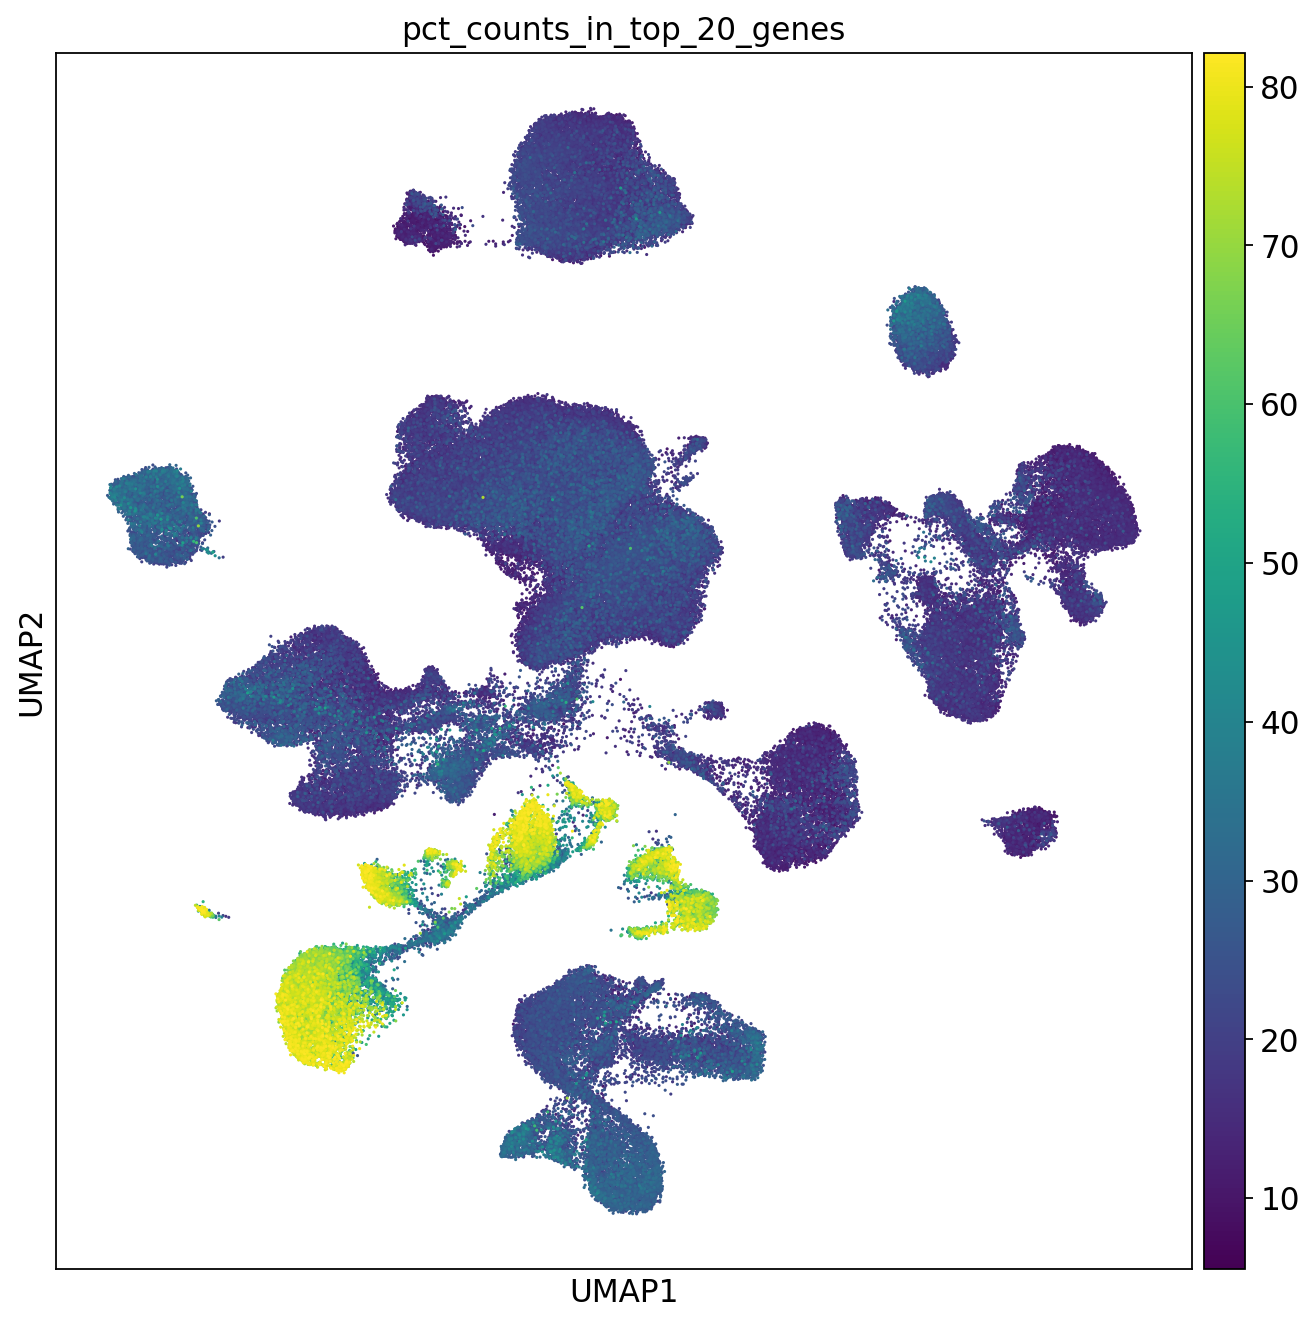

In [28]:
sc.pl.umap(adata, color=["pct_counts_in_top_20_genes"], size = 8)

In [ ]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=-1, resolution=0.5, random_state=42)

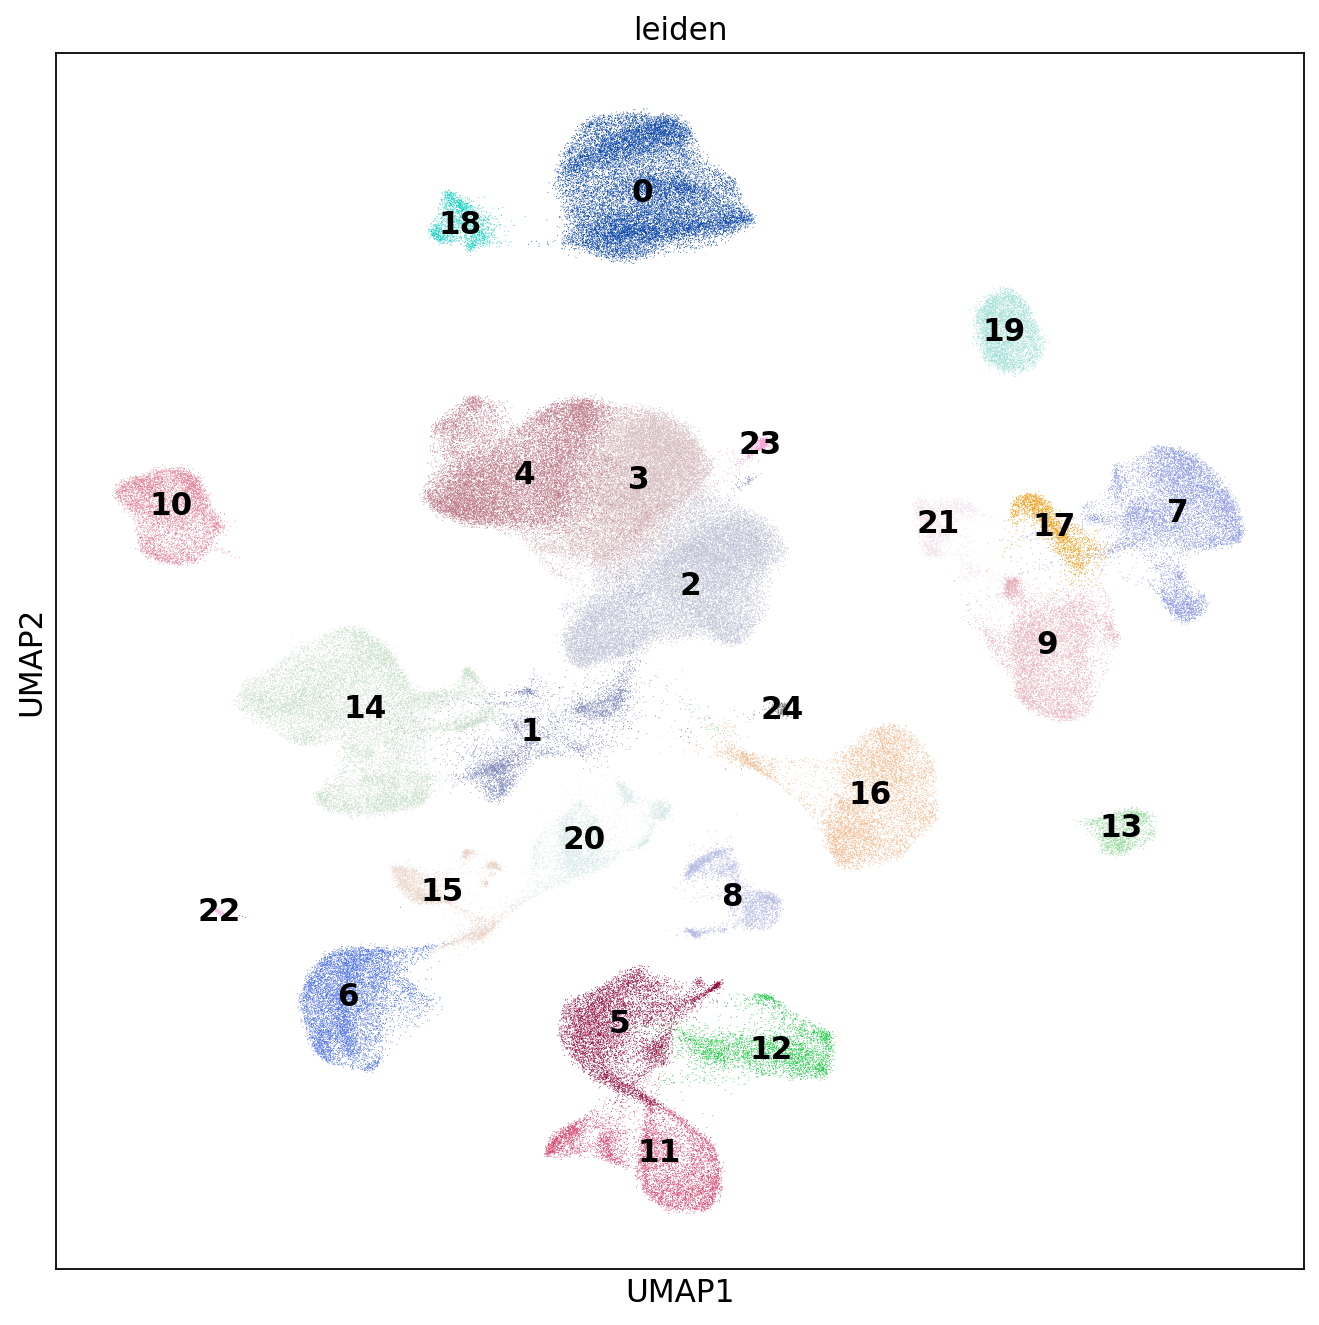

In [31]:
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
)

In [32]:
marker_genes = {
    "B cells" : ["CD79A", "MS4A1", "BANK1", "CD19", "VPREB3", "CD37"],
    "Endothelial cells" : ["VWF", "CLDN5", "PECAM1", "CCL2", "SPARCL1", "ACKR1"],
    "Enteric glial cells" : ["S100B", "SOX10", "GFAP", "PLP1", "CRYAB", "NRXN1", "GPM6B", "SCN7A"],
    "Epithelial cells" : ["EPCAM", "KRT8", "LGALS4", "FABP6", "PHGR1", "REG1A", "ALDOB", "FABP1"],
    "Mesenchymal cells" : ["LUM", "THY1", "ADAMDEC1", "COL1A1", "COL1A2", "COL3A1", "DCN", "CXCL14", "CFD"],
    "Myeloid cells" : ["CD68", "CSF1R", "LYZ", "C1QA", "S100A8", "S100A9", "CXCL8", "IL1B", "PLEK"],
    "Plasma cells" : ["MZB1", "DERL3", "IGLC2", "IGKC", "IGLC3", "JCHAIN", "IGHA1"],
    "T cells / ILC" : ["IL7R", "CD3E", "CD2", "CD4", "CD8A", "NKG7", "GNLY", "CCL5", "CD3D", "KLRB1"],
    "Mast_cells" : ["TPSAB1", "TPSB2"],
    "Neutrophils ❤️": ["CSF3R", "FCGR3B"]
}

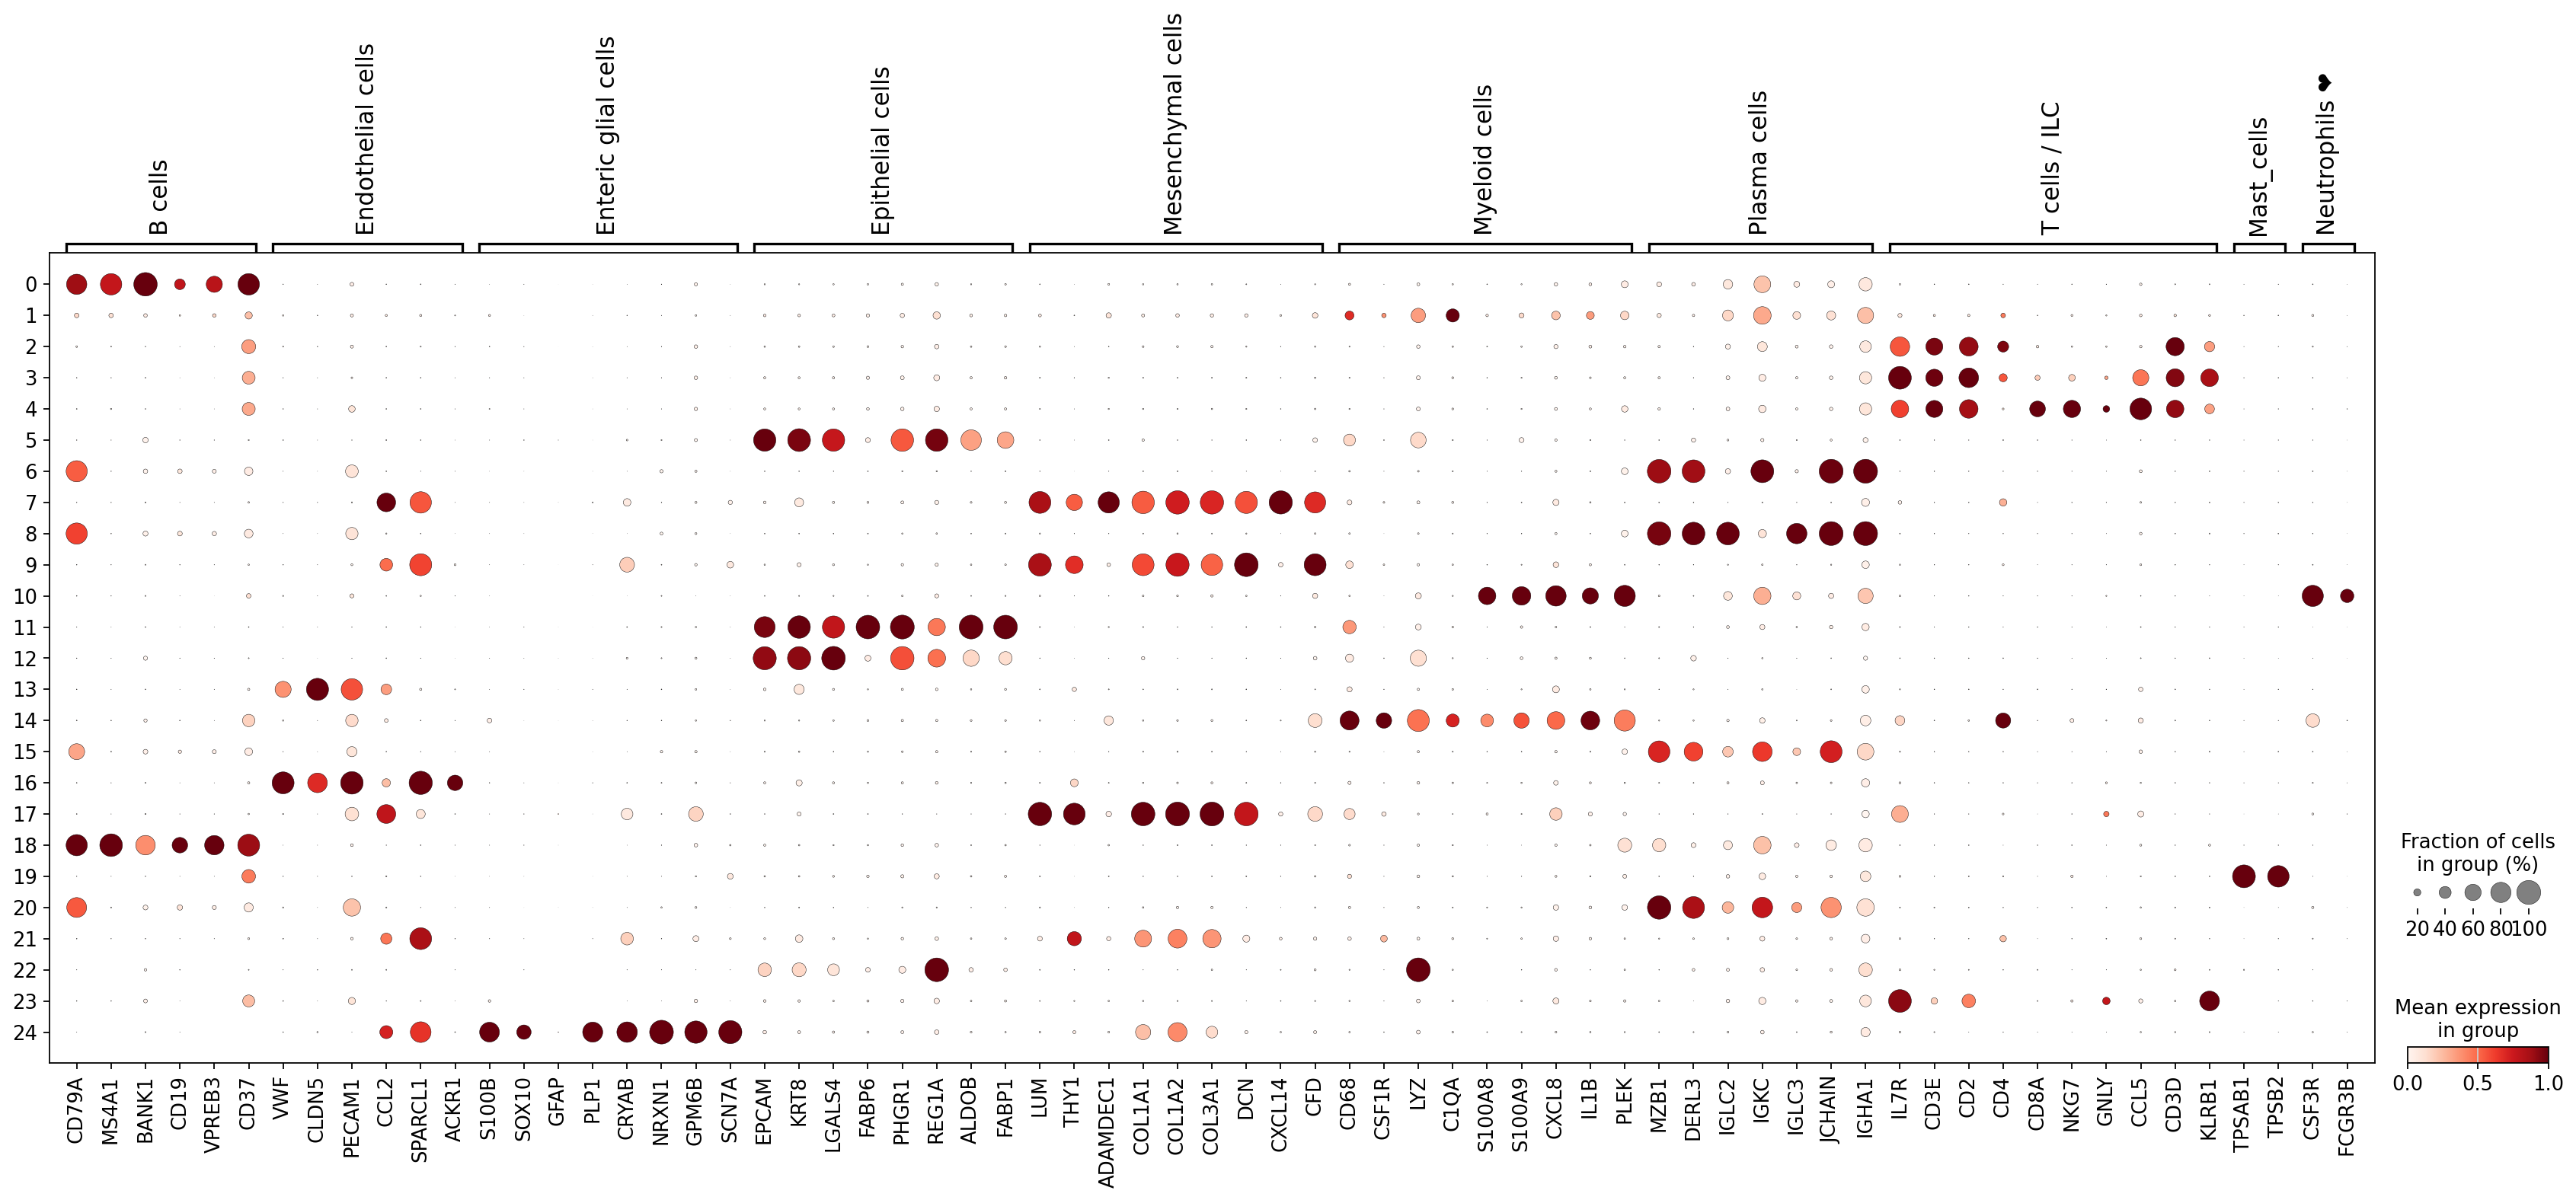

In [33]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden", standard_scale="var")

In [34]:
adata.obs["cell_type"] = adata.obs["leiden"].map(
    {
        "0": "B_cells",
        "1": "Myeloid_cells",
        "2": "T_cells_ILC",
        "3": "T_cells_ILC",
        "4": "T_cells_ILC",
        "5": "Epithelial_cells",
        "6": "Plasma_cells",
        "7": "Mesenchymal_cells",
        "8": "Plasma_cells",
        "9": "Mesenchymal_cells",
        "10": "Neutrophils ❤️",
        "11": "Epithelial_cells",
        "12": "Epithelial_cells",
        "13": "Endothelial_cells",
        "14": "Myeloid_cells",
        "15": "Plasma_cells",
        "16": "Endothelial_cells",
        "17": "Mesenchymal_cells",
        "18": "B_cells",
        "19": "Mast_cells",
        "20": "Plasma_cells",
        "21": "Mesenchymal_cells",
        "22": "Myeloid_cells",
        "23": "T_cells_ILC",
        "24": "Glial_cells"
    }
)

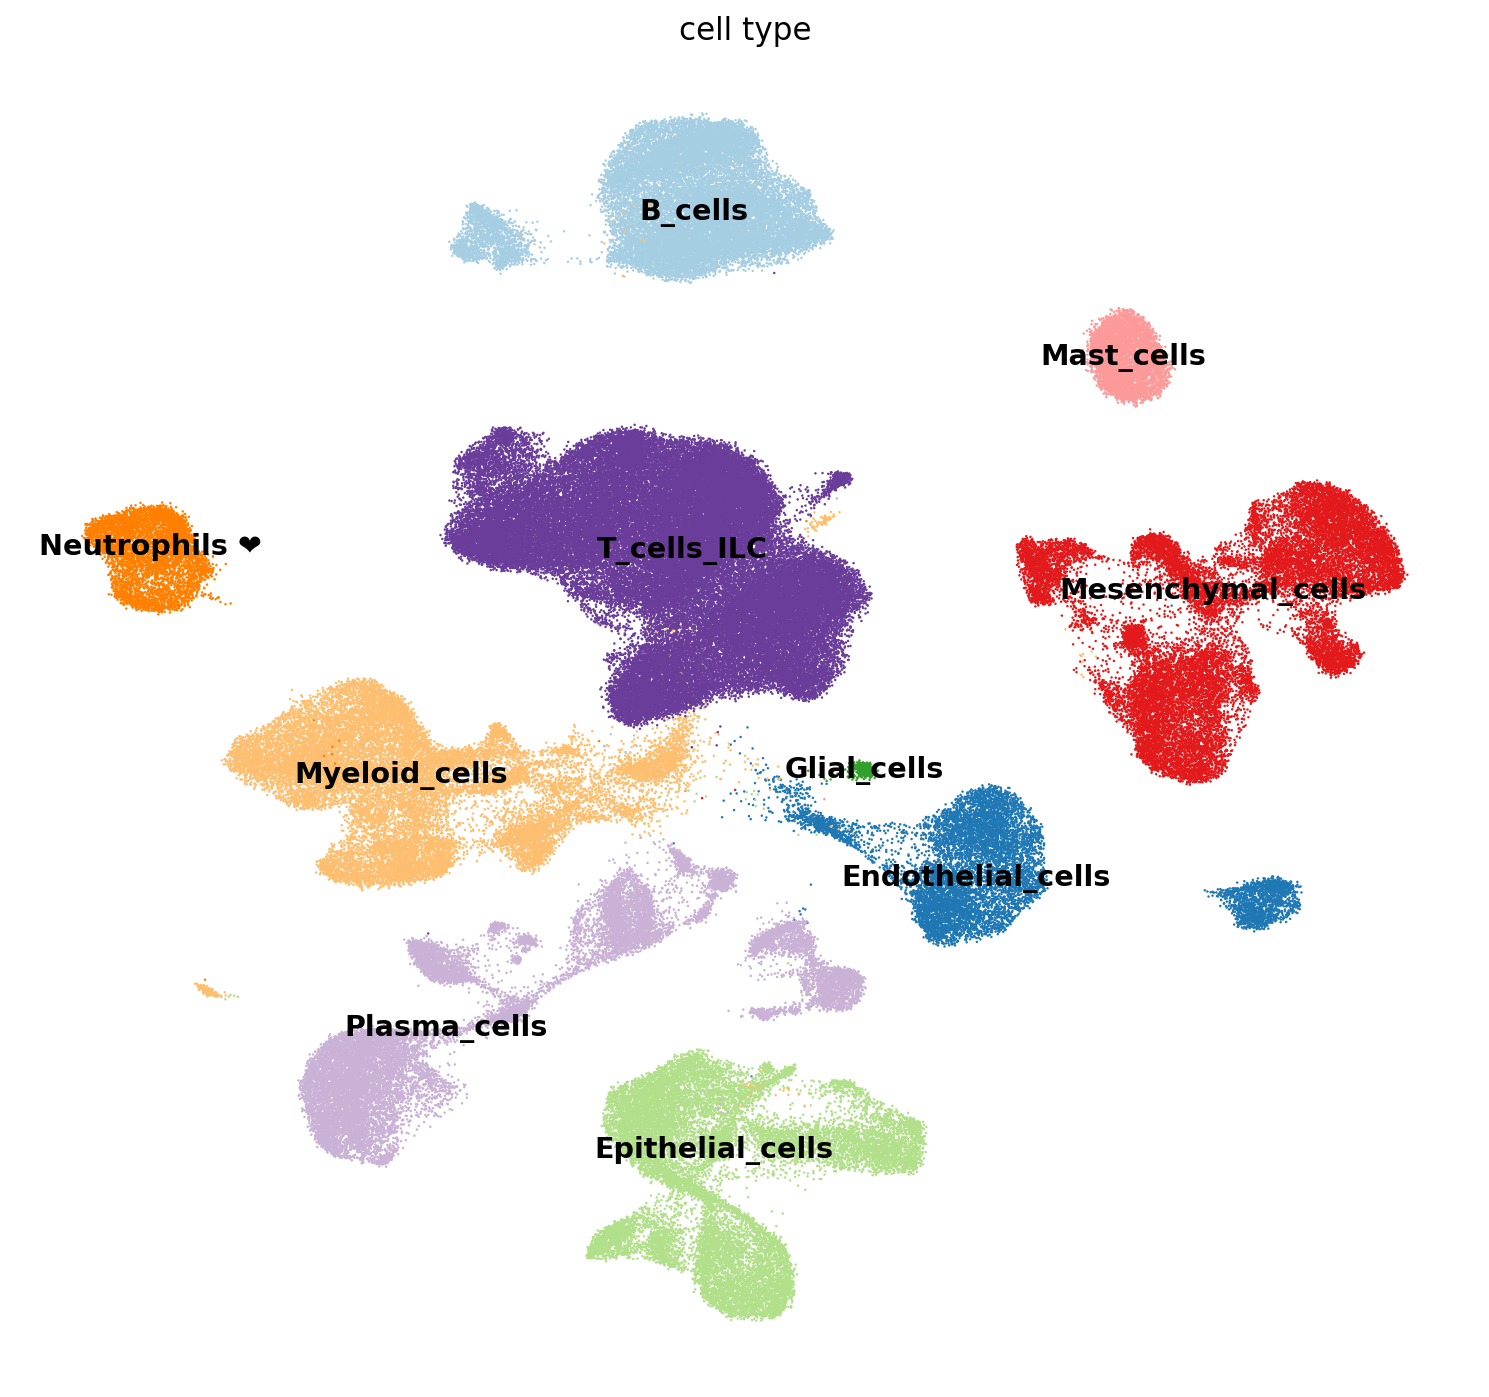

In [35]:
# get a pastel palette with as many colors as labels
categories = adata.obs["cell_type"].unique()
palette = sns.color_palette("Paired", n_colors=len(categories))

sc.pl.scatter(
    adata,
    color=["cell_type"],
    legend_loc='on data',
    palette = palette,
    frameon=False,
    basis='umap',
    size = 5)

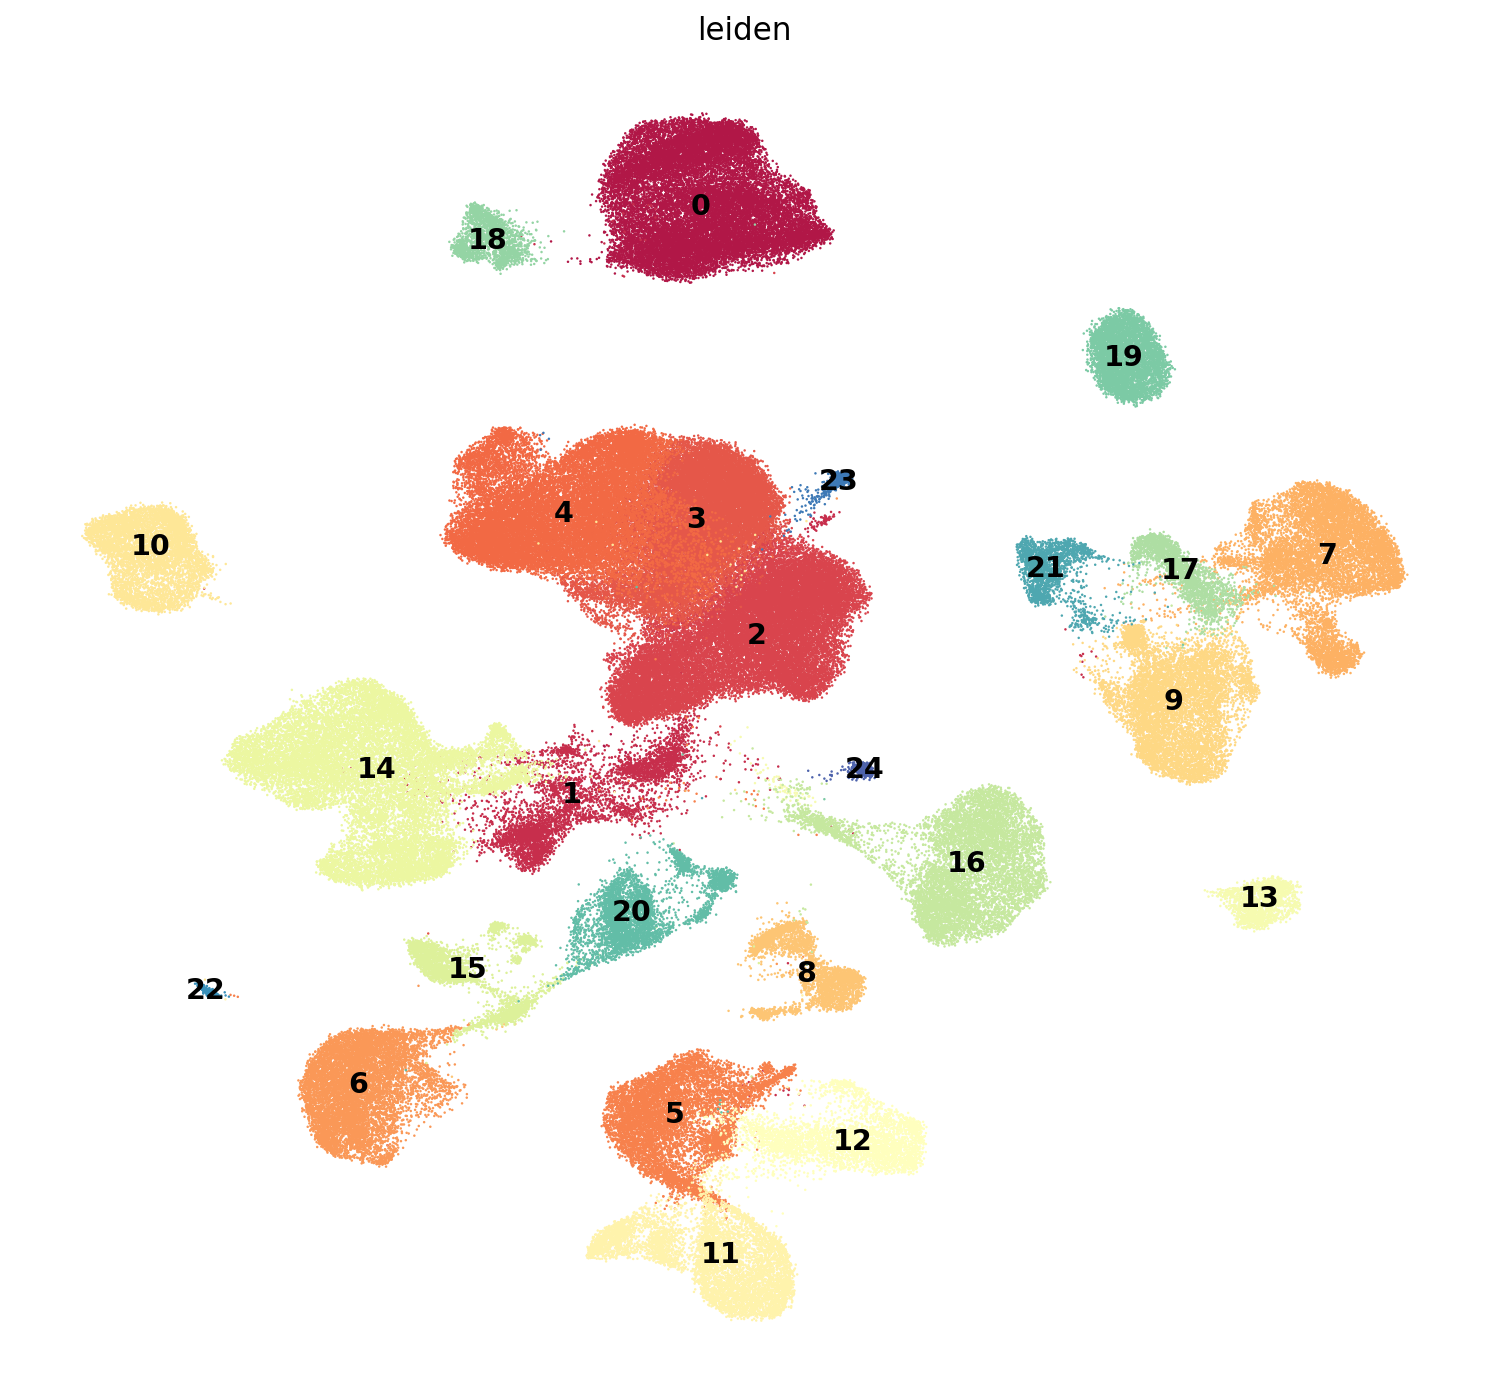

In [36]:
# get a pastel palette with as many colors as labels
categories = adata.obs["leiden"].unique()
palette = sns.color_palette("Spectral", n_colors=len(categories))

sc.pl.scatter(
    adata,
    color=["leiden"],
    legend_loc='on data',
    palette = palette,
    frameon=False,
    basis='umap',
    size = 5)

In [ ]:
###################### save

adata.write("../adata/IBD_preprocessing_dedoublet.h5ad")

In [38]:
adata

AnnData object with n_obs × n_vars = 183391 × 38606
    obs: 'sample', 'GC_Sample_Number', 'Gender', 'Date_of_surgery', 'Location', 'Disease', 'Segment', 'Age', 'Cells_prefix', 'Condition', 'Disease_segment', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'outlier_colors', 'mt_outlier', 'mt_outlier_colors', 'leiden', 'cell_type', 'scDblFinder_score', 'scDblFinder_class'
    var: 'gene_ids', 'feature_types', 'genome', 'gene_names', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'mt_outlier_colors_colors', 'neighbors', 'outlier_colors_colors', 'pca', 'sample_colors', 'scDblFinder_c